Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
 MÉTRICAS DE TREINAMENTO
Recall: 63.25%
F1-Score: 50.12%

MÉTRICAS DE TESTE
Acurácia: 73.70%
Precisão: 32.28%
Recall (Sensibilidade): 57.75%
F1-Score: 41.41%

MATRIZ DE CONFUSÃO (TESTE)
Verdadeiros Negativos (Real Fica, Previsto Fica) : 284
Falsos Positivos    (Real Fica, Previsto Sai)  : 86
Falsos Negativos    (Real Sai, Previsto Fica)  : 30
Verdadeiros Positivos (Real Sai, Previsto Sai)   : 41

Árvore de decisão salva como 'arvore_hr_analise.png'


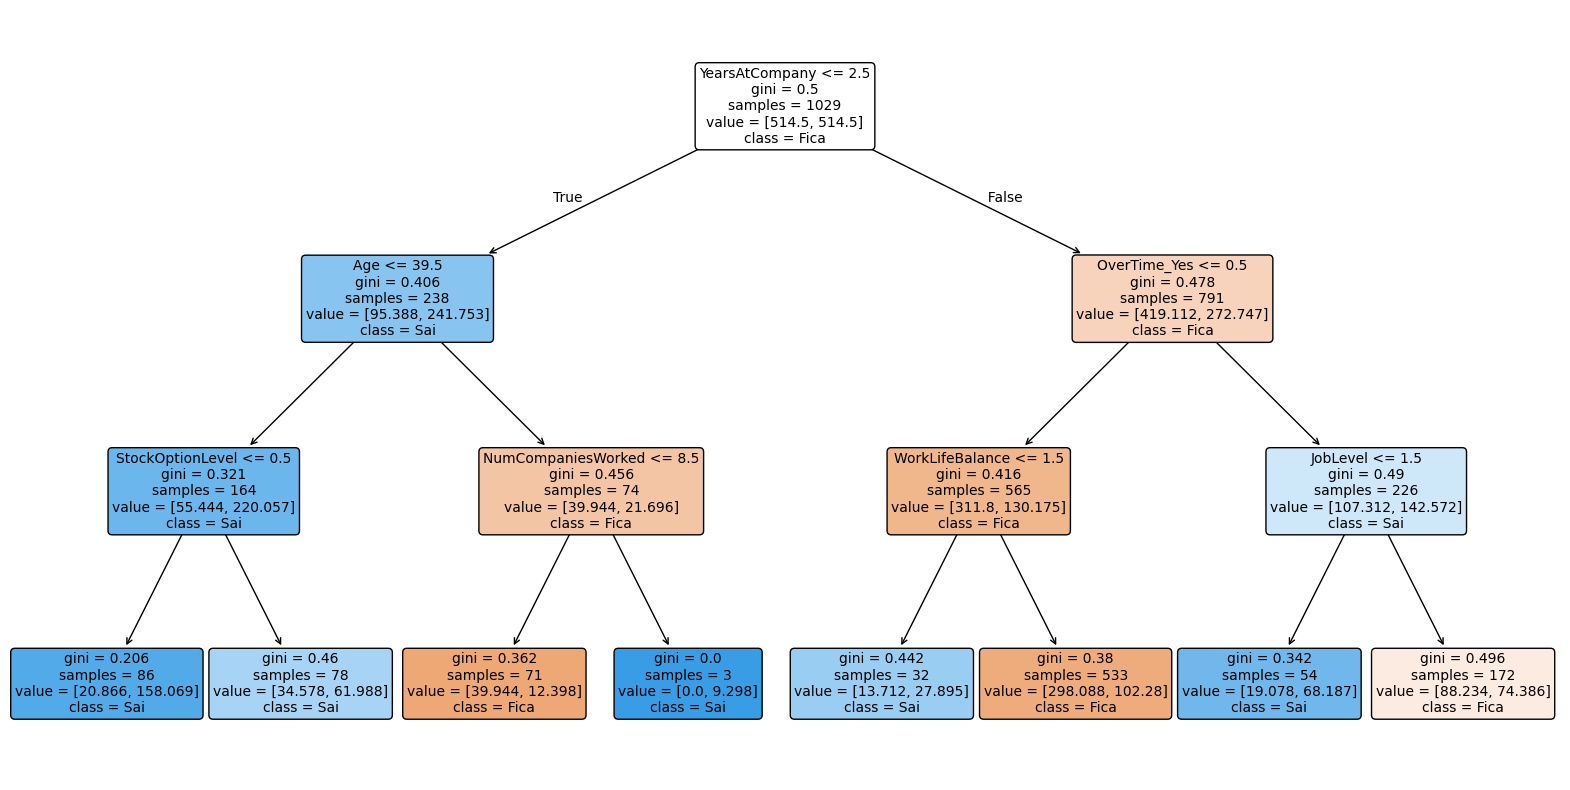

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
#import kagglehub

#path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

#csv_file = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')][0]
#df = pd.read_csv(csv_file)
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# separação variáveis preditoras da variável alvo
colunas_inuteis = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
X = df.drop(columns=['Attrition'] + [col for col in colunas_inuteis if col in df.columns])
y = df['Attrition'] 

X = pd.get_dummies(X, drop_first=True)

# divisão 70 treino 30 teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

cart_hr = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    class_weight="balanced",
    random_state=42
)
cart_hr.fit(X_train, y_train)


# métricas
y_train_pred = cart_hr.predict(X_train)
recall_treino = recall_score(y_train, y_train_pred)
f1_treino = f1_score(y_train, y_train_pred)

print(" MÉTRICAS DE TREINAMENTO")
print(f"Recall: {recall_treino:.2%}")
print(f"F1-Score: {f1_treino:.2%}\n")

y_test_pred = cart_hr.predict(X_test)
acc_teste = accuracy_score(y_test, y_test_pred)
prec_teste = precision_score(y_test, y_test_pred)
recall_teste = recall_score(y_test, y_test_pred)
f1_teste = f1_score(y_test, y_test_pred)

print("MÉTRICAS DE TESTE")
print(f"Acurácia: {acc_teste:.2%}")
print(f"Precisão: {prec_teste:.2%}")
print(f"Recall (Sensibilidade): {recall_teste:.2%}")
print(f"F1-Score: {f1_teste:.2%}\n")

# matriz de Confusão
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print("MATRIZ DE CONFUSÃO (TESTE)")
print(f"Verdadeiros Negativos (Real Fica, Previsto Fica) : {tn}")
print(f"Falsos Positivos    (Real Fica, Previsto Sai)  : {fp}")
print(f"Falsos Negativos    (Real Sai, Previsto Fica)  : {fn}")
print(f"Verdadeiros Positivos (Real Sai, Previsto Sai)   : {tp}\n")


plt.figure(figsize=(20, 10))
plot_tree(
    cart_hr,
    feature_names=X.columns,
    class_names=["Fica", "Sai"],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=False
)

plt.savefig("arvore_hr_analise.png", dpi=300, bbox_inches="tight")
print("Árvore de decisão salva como 'arvore_hr_analise.png'")